In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
fraud = pd.read_csv("../data/raw/Fraud_Data.csv")

ip_country = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

credit = pd.read_csv("../data/raw/creditcard.csv")

In [40]:
fraud.info()
fraud.isnull().sum()
fraud.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


np.int64(0)

In [41]:
fraud = fraud.drop_duplicates()

Convert datetimes

In [42]:
fraud["signup_time"] = pd.to_datetime(fraud["signup_time"])
fraud["purchase_time"] = pd.to_datetime(fraud["purchase_time"])

EDA

In [43]:
fraud["class"].value_counts(normalize=True)

class
0    0.906354
1    0.093646
Name: proportion, dtype: float64

dataset is highly imbalanced
fraud cases are minority

Purchase value distribution

In [44]:
fraud["purchase_value"].describe()

count    151112.000000
mean         36.935372
std          18.322762
min           9.000000
25%          22.000000
50%          35.000000
75%          49.000000
max         154.000000
Name: purchase_value, dtype: float64

Fraud rate by browser/source

In [45]:
fraud.groupby("browser")["class"].mean()
fraud.groupby("source")["class"].mean()

source
Ads       0.092066
Direct    0.105370
SEO       0.089285
Name: class, dtype: float64

Time-based fraud patterns

In [46]:
fraud["hour"] = fraud["purchase_time"].dt.hour

In [47]:
fraud.groupby("hour")["class"].mean()

hour
0     0.089395
1     0.089917
2     0.091985
3     0.095076
4     0.082975
5     0.089837
6     0.093103
7     0.088173
8     0.101456
9     0.105796
10    0.099672
11    0.089142
12    0.094331
13    0.090750
14    0.095201
15    0.099074
16    0.098748
17    0.107485
18    0.095649
19    0.096841
20    0.081820
21    0.091099
22    0.085404
23    0.093167
Name: class, dtype: float64

GEOLOCATION INTEGRATION

In [48]:
fraud["ip_address"] = fraud["ip_address"].astype(int)
ip_country["lower_bound_ip_address"] = ip_country["lower_bound_ip_address"].astype(int)
ip_country["upper_bound_ip_address"] = ip_country["upper_bound_ip_address"].astype(int)

In [49]:
fraud = fraud.sort_values("ip_address")
ip_country = ip_country.sort_values("lower_bound_ip_address")

In [50]:
fraud_geo = pd.merge_asof(
    fraud,
    ip_country,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

Filter invalid matches

In [51]:
fraud_geo = fraud_geo[
    fraud_geo["ip_address"] <= fraud_geo["upper_bound_ip_address"]
]

Country fraud analysis

In [52]:
fraud_geo.groupby("country")["class"].mean().sort_values(ascending=False).head(10)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

FEATURE ENGINEERING

Time-based features

In [53]:
fraud_geo["time_since_signup"] = (
    fraud_geo["purchase_time"] - fraud_geo["signup_time"]
).dt.total_seconds() / 3600

fraud_geo["hour_of_day"] = fraud_geo["purchase_time"].dt.hour
fraud_geo["day_of_week"] = fraud_geo["purchase_time"].dt.dayofweek

Behavioral features

In [54]:
fraud_geo["user_transaction_count"] = fraud_geo.groupby("user_id")["user_id"].transform("count")
fraud_geo["device_transaction_count"] = fraud_geo.groupby("device_id")["device_id"].transform("count")
fraud_geo["ip_transaction_count"] = fraud_geo.groupby("ip_address")["ip_address"].transform("count")

PREPROCESSING

In [55]:
df = fraud_geo.drop(["signup_time", "purchase_time", "device_id"], axis=1)

In [56]:
df = fraud_geo.drop(["signup_time", "purchase_time", "device_id"], axis=1)

Train-test split

In [57]:
from sklearn.model_selection import train_test_split

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

SCALING

In [58]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    "purchase_value",
    "age",
    "time_since_signup",
    "user_transaction_count",
    "device_transaction_count",
    "ip_transaction_count"
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

SMOTE

In [64]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [65]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [66]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Document imbalance

In [68]:
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

Before SMOTE:
 class
0    93502
1     9814
Name: count, dtype: int64

After SMOTE:
 class
0    93502
1    93502
Name: count, dtype: int64


In [75]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/fraud_processed.csv", index=False)

fraud distribution look like

<Axes: xlabel='class'>

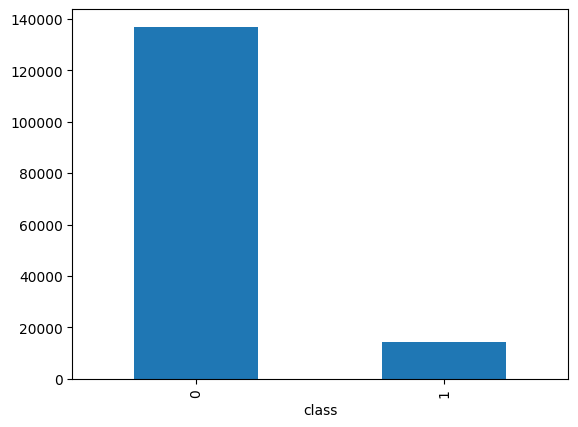

In [76]:
fraud["class"].value_counts().plot(kind="bar")

How fraud relate to transaction value

<Axes: xlabel='class', ylabel='purchase_value'>

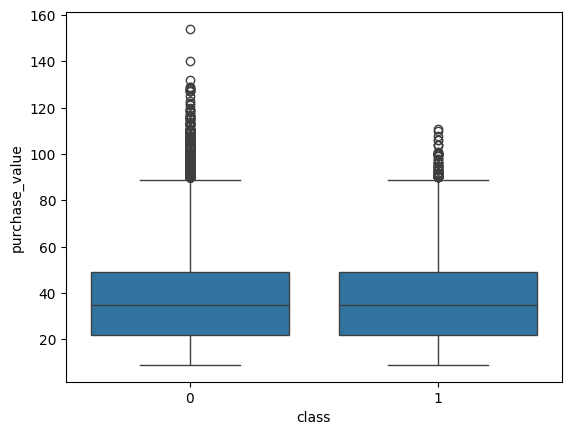

In [77]:
import seaborn as sns

sns.boxplot(x="class", y="purchase_value", data=fraud)

When does fraud happen

<Axes: xlabel='hour'>

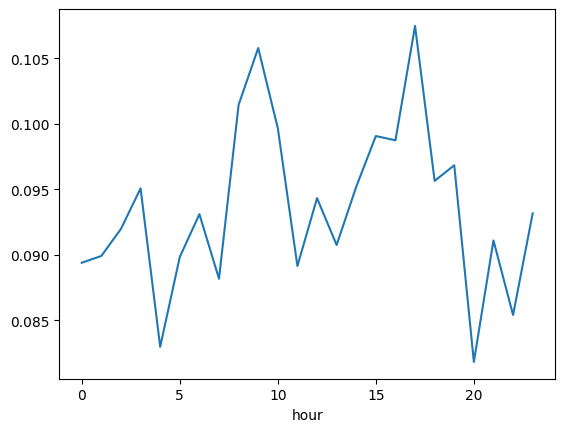

In [78]:
fraud["hour"] = fraud["purchase_time"].dt.hour

fraud.groupby("hour")["class"].mean().plot()

Which sources or browsers are risky

<Axes: xlabel='browser'>

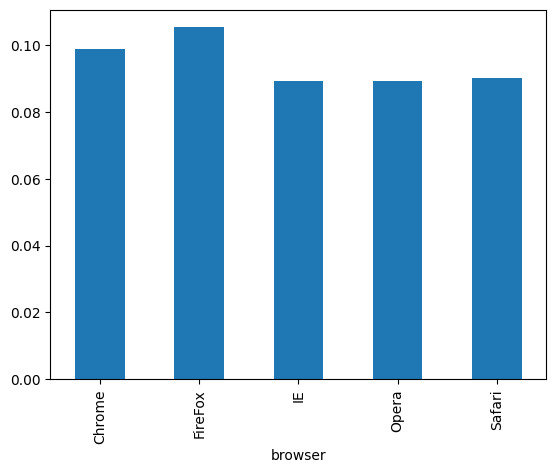

In [79]:
fraud.groupby("source")["class"].mean().plot(kind="bar")
fraud.groupby("browser")["class"].mean().plot(kind="bar")

Geolocation insight (after merge)

<Axes: xlabel='country'>

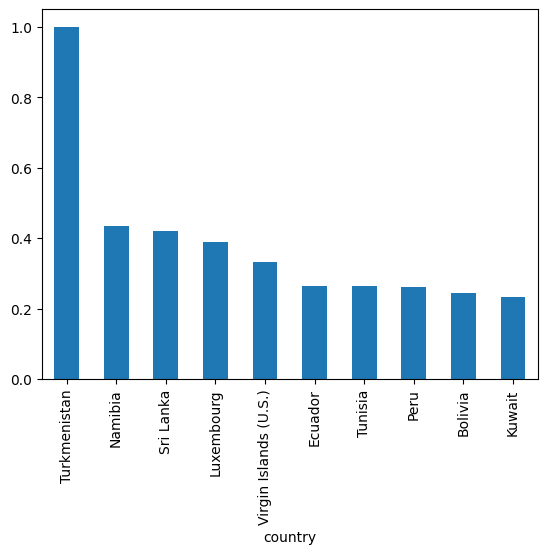

In [80]:
fraud_geo.groupby("country")["class"].mean().sort_values(ascending=False).head(10).plot(kind="bar")

Fraud is heavily concentrated in a small number of transactions, confirming severe class imbalance. This justifies the use of SMOTE and AUC-PR as evaluation metrics.

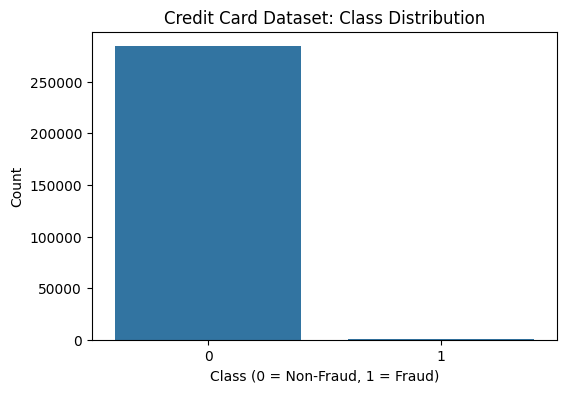

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=creditcard)
plt.title("Credit Card Dataset: Class Distribution")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

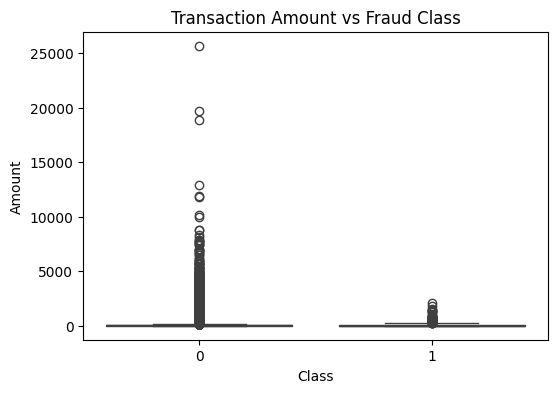

In [87]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Class", y="Amount", data=creditcard)
plt.title("Transaction Amount vs Fraud Class")
plt.show()

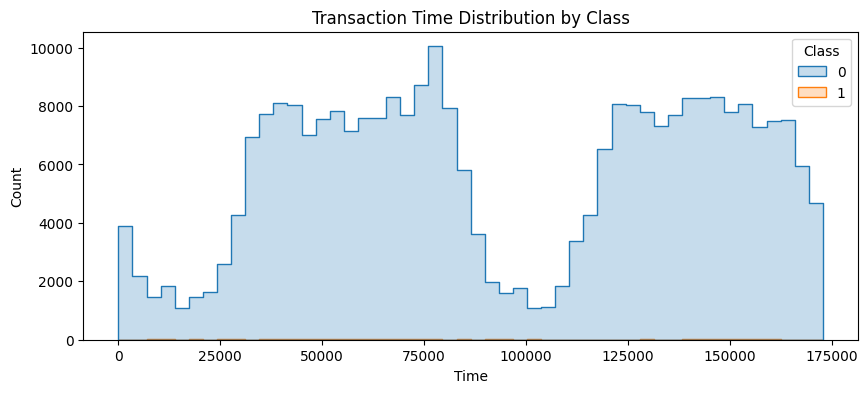

In [88]:
plt.figure(figsize=(10,4))
sns.histplot(data=creditcard, x="Time", hue="Class", bins=50, element="step")
plt.title("Transaction Time Distribution by Class")
plt.show()